  RASAero CDX1: JUMP.CDX1
  Nose  : Conical, L=10.85 in  D=2.12 in
  Body  : L=15.00 in  D=2.12 in
  Motor : L2523  (BPS)
  Launch mass : 11.00 lb  (4.99 kg)
  CG (nose-to-tail): 36.00 in  (0.9144 m)
  Total length  : 0.6566 m
  Rocket radius : 0.0270 m
[INFO] Using CDX1 launch weight as rocket mass proxy: 4.990 kg  — replace with actual dry mass!
[WARN] inertia_i not supplied; using rough estimate 0.1802 kg·m² — provide accurate value!
[WARN] inertia_z not supplied; using rough estimate 0.001817 kg·m² — provide accurate value!

[NoseCone] kind=conical  L=0.2756 m  tip_position=0.3283 m (RocketPy)
[WARN] No fins found in CDX1 file.
[INFO] No boattail / tail surface added.

✅  Rocket built.  Remember to attach a motor:
    rocket.add_motor(motor, position=<nozzle_exit_position_m>)


Inertia Details

Rocket Mass: 4.990 kg (without motor)
Rocket Dry Mass: 4.990 kg (with unloaded motor)
Rocket Loaded Mass: 4.990 kg
Rocket Structural Mass Ratio: 1.000
Rocket Inertia (with unloaded motor) 11

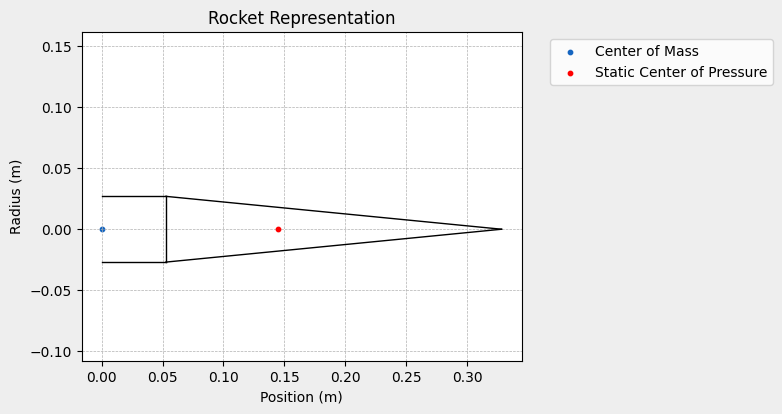

── CDX1 raw values ──────────────────────────────────────────
  Motor            : L2523  (BPS)
  Launch weight    : 11.00 lb  (4.990 kg)
  CG (nose-to-tail): 36.00 in  (0.9144 m)
  Nozzle diameter  : 1.900 in  (4.83 cm)
  Launch altitude  : 2000 ft  (609.6 m)
  Rail angle       : 2.0°
  Rail length      : 20.0 ft  (6.10 m)
─────────────────────────────────────────────────────────────


In [ ]:
# %% [markdown]
# # RASAero II CDX1 → RocketPy Converter
#
# This notebook parses a RASAero II `.CDX1` design file and reconstructs
# the rocket as RocketPy objects ready for simulation.
#
# **Units note:** RASAero stores all lengths in **inches** and masses in **pounds**.
# RocketPy expects **meters** and **kilograms**.  The parser converts automatically.
#
# **Coordinate system:** RocketPy defaults to `"tail_to_nose"` with the origin at
# the center of dry mass.  Positions derived here use `"nose_to_tail"` internally,
# then flip to match RocketPy's convention once the total rocket length is known.

# %% [markdown]
# ## 1 · Imports

# %%
import xml.etree.ElementTree as ET
from pathlib import Path
import numpy as np

# RocketPy imports — install with:  pip install rocketpy
from rocketpy import Rocket
from rocketpy.rocket.aero_surface import NoseCone, TrapezoidalFins, Tail

# %% [markdown]
# ## 2 · Unit-conversion helpers

# %%
IN2M  = 0.0254          # inches  → metres
LB2KG = 0.453592        # pounds  → kilograms
IN2M2 = IN2M ** 2       # in²    → m²

def in_to_m(value: float) -> float:
    """Convert inches to metres."""
    return float(value) * IN2M

def lb_to_kg(value: float) -> float:
    """Convert pounds to kilograms."""
    return float(value) * LB2KG

def _float(element, tag: str, default: float = 0.0) -> float:
    """Safely read a float child tag; return *default* if missing or empty."""
    node = element.find(tag)
    if node is None or not (node.text or "").strip():
        return default
    return float(node.text.strip())

def _str(element, tag: str, default: str = "") -> str:
    node = element.find(tag)
    return (node.text or "").strip() if node is not None else default

# %% [markdown]
# ## 3 · CDX1 parser

# %%
class CDX1Parser:
    """
    Parses a RASAero II CDX1 XML file and exposes structured data for each
    rocket component and the first simulation entry.

    Parameters
    ----------
    filepath : str or Path
        Path to the .CDX1 file.
    """

    def __init__(self, filepath):
        self.filepath = Path(filepath)
        tree = ET.parse(self.filepath)
        self.root = tree.getroot()
        design = self.root.find("RocketDesign")
        if design is None:
            raise ValueError("No <RocketDesign> element found in CDX1 file.")
        self._design = design
        self._parse()

    # ------------------------------------------------------------------
    # Internal parsing
    # ------------------------------------------------------------------

    def _parse(self):
        d = self._design
        self._parse_nose(d.find("NoseCone"))
        self._parse_body(d.find("BodyTube"))
        self._parse_fincan(d.find("FinCan"))
        self._parse_simulation()
        self._parse_launch_site()
        self._parse_recovery()

    def _parse_nose(self, node):
        if node is None:
            raise ValueError("CDX1 file has no <NoseCone> section.")
        self.nose = {
            "length_in":   _float(node, "Length"),
            "diameter_in": _float(node, "Diameter"),
            "shape":       _str(node, "Shape", "Conical"),
            "location_in": _float(node, "Location"),   # nose tip from origin
        }

    def _parse_body(self, node):
        if node is None:
            raise ValueError("CDX1 file has no <BodyTube> section.")
        self.body = {
            "length_in":         _float(node, "Length"),
            "diameter_in":       _float(node, "Diameter"),
            "location_in":       _float(node, "Location"),
            "boattail_length_in":_float(node, "BoattailLength"),
            "boattail_rear_dia_in": _float(node, "BoattailRearDiameter"),
        }

    def _parse_fincan(self, node):
        if node is None:
            # RASAero designs may have fins directly on the body
            self.fincan = None
            self.fins   = None
            return
        self.fincan = {
            "length_in":          _float(node, "Length"),
            "diameter_in":        _float(node, "Diameter"),
            "inside_diameter_in": _float(node, "InsideDiameter"),
            "location_in":        _float(node, "Location"),
            "shoulder_length_in": _float(node, "ShoulderLength"),
            "offset_in":          _float(node, "Offset"),
        }
        fin_node = node.find("Fin")
        if fin_node is not None:
            self.fins = {
                "count":          int(_float(fin_node, "Count", 3)),
                "root_chord_in":  _float(fin_node, "Chord"),
                "tip_chord_in":   _float(fin_node, "TipChord"),
                "span_in":        _float(fin_node, "Span"),
                "sweep_in":       _float(fin_node, "SweepDistance"),
                "thickness_in":   _float(fin_node, "Thickness"),
                "location_in":    _float(fin_node, "Location"),  # from fincan front
                "airfoil_section":_str(fin_node, "AirfoilSection", "Flat"),
            }
        else:
            self.fins = None

    def _parse_simulation(self):
        sim_list = self.root.find("SimulationList")
        self.simulation = None
        if sim_list is None:
            return
        sim = sim_list.find("Simulation")
        if sim is None:
            return
        self.simulation = {
            "engine":           _str(sim, "SustainerEngine"),
            "launch_weight_lb": _float(sim, "SustainerLaunchWt"),
            "cg_in":            _float(sim, "SustainerCG"),
            "nozzle_dia_in":    _float(sim, "SustainerNozzleDiameter"),
        }

    def _parse_launch_site(self):
        site = self.root.find("LaunchSite")
        self.launch_site = None
        if site is None:
            return
        self.launch_site = {
            "altitude_ft":    _float(site, "Altitude"),
            "rod_angle_deg":  _float(site, "RodAngle"),
            "rod_length_ft":  _float(site, "RodLength"),
            "temperature_f":  _float(site, "Temperature", 59),
            "wind_speed_mph": _float(site, "WindSpeed"),
        }

    def _parse_recovery(self):
        rec = self.root.find("Recovery")
        self.recovery = None
        if rec is None:
            return
        self.recovery = {
            "device_type_1": _str(rec, "DeviceType1", "None"),
            "size_1_in":     _float(rec, "Size1", 1),
            "cd_1":          _float(rec, "CD1", 1.33),
            "altitude_1_ft": _float(rec, "Altitude1", 1000),
            "device_type_2": _str(rec, "DeviceType2", "None"),
            "size_2_in":     _float(rec, "Size2", 1),
            "cd_2":          _float(rec, "CD2", 1.33),
            "altitude_2_ft": _float(rec, "Altitude2", 0),
        }

    # ------------------------------------------------------------------
    # Derived geometry (all in metres, nose-to-tail positive)
    # ------------------------------------------------------------------

    @property
    def rocket_radius_m(self) -> float:
        """Max body radius in metres (uses body tube diameter)."""
        return in_to_m(self.body["diameter_in"]) / 2.0

    @property
    def total_length_m(self) -> float:
        """Overall rocket length nose-tip to tail in metres."""
        nose_len  = in_to_m(self.nose["length_in"])
        body_len  = in_to_m(self.body["length_in"])
        if self.fincan:
            fin_len = in_to_m(self.fincan["length_in"])
        else:
            fin_len = 0.0
        return nose_len + body_len + fin_len

    def summary(self):
        """Print a human-readable summary of parsed parameters."""
        print("=" * 60)
        print(f"  RASAero CDX1: {self.filepath.name}")
        print("=" * 60)
        print(f"  Nose  : {self.nose['shape']}, L={self.nose['length_in']:.2f} in"
              f"  D={self.nose['diameter_in']:.2f} in")
        print(f"  Body  : L={self.body['length_in']:.2f} in"
              f"  D={self.body['diameter_in']:.2f} in")
        if self.fincan and self.fins:
            f = self.fins
            print(f"  Fins  : {f['count']}× trapezoid"
                  f"  root={f['root_chord_in']:.2f} in"
                  f"  tip={f['tip_chord_in']:.2f} in"
                  f"  span={f['span_in']:.2f} in"
                  f"  sweep={f['sweep_in']:.2f} in")
        if self.simulation:
            s = self.simulation
            print(f"  Motor : {s['engine']}")
            print(f"  Launch mass : {s['launch_weight_lb']:.2f} lb"
                  f"  ({lb_to_kg(s['launch_weight_lb']):.2f} kg)")
            print(f"  CG (nose-to-tail): {s['cg_in']:.2f} in"
                  f"  ({in_to_m(s['cg_in']):.4f} m)")
        print(f"  Total length  : {self.total_length_m:.4f} m")
        print(f"  Rocket radius : {self.rocket_radius_m:.4f} m")
        print("=" * 60)


# %% [markdown]
# ## 4 · RocketPy shape-code mapper

# %%
NOSE_SHAPE_MAP = {
    # RASAero label  →  RocketPy kind string
    "Conical":      "conical",
    "Ogive":        "ogive",
    "Tangent Ogive":"ogive",
    "Power Series": "powerseries",
    "Parabolic":    "parabolic",
    "Von Karman":   "vonkarman",
    "Haack":        "lvhaack",
    "Elliptical":   "elliptical",
}

def rasaero_nose_kind(rasaero_shape: str) -> str:
    """Map a RASAero nose shape string to a RocketPy kind string."""
    kind = NOSE_SHAPE_MAP.get(rasaero_shape)
    if kind is None:
        print(f"[WARN] Unknown nose shape '{rasaero_shape}'; defaulting to 'conical'.")
        kind = "conical"
    return kind


# %% [markdown]
# ## 5 · Main builder function

# %%
def build_rocketpy_rocket(
    cdx1_path: str,
    *,
    mass_kg:          float | None = None,
    inertia_i_kg_m2:  float | None = None,
    inertia_z_kg_m2:  float | None = None,
    center_of_dry_mass_position: float = 0.0,
    coordinate_system_orientation: str = "tail_to_nose",
    power_off_drag = 0.5,
    power_on_drag  = 0.5,
    add_tail: bool = True,
) -> tuple["Rocket", CDX1Parser]:
    """
    Parse a RASAero II CDX1 file and return a configured RocketPy ``Rocket``
    object together with the :class:`CDX1Parser` for further inspection.

    Parameters
    ----------
    cdx1_path : str
        Path to the ``.CDX1`` file.
    mass_kg : float, optional
        Rocket dry mass (structure + empty motor) in kg.
        If omitted, the launch weight from the CDX1 simulation block is used
        as a *proxy* (launch weight ≈ total loaded mass; adjust as needed).
    inertia_i_kg_m2 : float, optional
        Rocket lateral moment of inertia (I₁₁ = I₂₂) in kg·m².
        RASAero does not store this; provide it or set it after the call.
    inertia_z_kg_m2 : float, optional
        Rocket axial moment of inertia (I₃₃) in kg·m².
    center_of_dry_mass_position : float
        Position of the rocket's center of dry mass within the user coordinate
        system, in metres.  Default 0 (origin at CoM).
    coordinate_system_orientation : str
        RocketPy coordinate orientation.  ``"tail_to_nose"`` (default) means
        the nose is in the +Z direction.
    power_off_drag : float or str
        Drag coefficient (or CSV path) when motor is off.  RASAero does not
        export a drag curve in CDX1 format; supply one separately if needed.
    power_on_drag : float or str
        Drag coefficient (or CSV path) when motor is on.
    add_tail : bool
        Whether to add a ``Tail`` surface for the boattail (if present in the
        CDX1 data).  Defaults to ``True``.

    Returns
    -------
    rocket : rocketpy.Rocket
        Fully configured Rocket object (motor *not* added — attach your own).
    parser : CDX1Parser
        The parser object with all raw and converted values.

    Notes
    -----
    *Inertia values must be supplied externally.*  RASAero does not record
    moments of inertia in the CDX1 file.  Use OpenRocket, RASAero Pro, or a
    hand calculation to obtain them, then pass them here or set:

        rocket.I_11 = your_value  # kg·m²
        rocket.I_33 = your_value  # kg·m²

    The motor must be added after this call::

        rocket.add_motor(my_motor, position=<nozzle_position_m>)
    """

    parser = CDX1Parser(cdx1_path)
    parser.summary()

    # ------------------------------------------------------------------ #
    # Mass                                                                 #
    # ------------------------------------------------------------------ #
    if mass_kg is None:
        if parser.simulation and parser.simulation["launch_weight_lb"] > 0:
            mass_kg = lb_to_kg(parser.simulation["launch_weight_lb"])
            print(f"[INFO] Using CDX1 launch weight as rocket mass proxy: "
                  f"{mass_kg:.3f} kg  — replace with actual dry mass!")
        else:
            raise ValueError(
                "mass_kg not provided and no launch weight found in CDX1 file. "
                "Please pass mass_kg explicitly."
            )

    # ------------------------------------------------------------------ #
    # Inertia defaults (rough estimate if not supplied)                    #
    # ------------------------------------------------------------------ #
    L = parser.total_length_m
    R = parser.rocket_radius_m

    if inertia_i_kg_m2 is None:
        # Very rough thin-walled cylinder approximation:  I ≈ m*(3R²+L²)/12
        inertia_i_kg_m2 = mass_kg * (3 * R**2 + L**2) / 12.0
        print(f"[WARN] inertia_i not supplied; using rough estimate "
              f"{inertia_i_kg_m2:.4f} kg·m² — provide accurate value!")

    if inertia_z_kg_m2 is None:
        # Solid cylinder approximation:  I_z ≈ m*R²/2
        inertia_z_kg_m2 = mass_kg * R**2 / 2.0
        print(f"[WARN] inertia_z not supplied; using rough estimate "
              f"{inertia_z_kg_m2:.6f} kg·m² — provide accurate value!")

    # ------------------------------------------------------------------ #
    # Build Rocket object                                                   #
    # ------------------------------------------------------------------ #
    rocket = Rocket(
        radius=R,
        mass=mass_kg,
        inertia=(inertia_i_kg_m2, inertia_i_kg_m2, inertia_z_kg_m2),
        power_off_drag=power_off_drag,
        power_on_drag=power_on_drag,
        center_of_mass_without_motor=center_of_dry_mass_position,
        coordinate_system_orientation=coordinate_system_orientation,
    )

    # ------------------------------------------------------------------ #
    # Coordinate system bookkeeping                                         #
    #                                                                       #
    # RASAero stores locations as "distance from nose tip" (nose-to-tail). #
    # RocketPy uses the user-defined coordinate system.  With              #
    # coordinate_system_orientation="tail_to_nose" and origin at CoM,      #
    # we must convert positions.                                            #
    #                                                                       #
    # nose_tip_pos  = +L/2   (nose is in +Z direction)                     #
    # tail_pos      = -L/2                                                  #
    # any point p_nt (nose-to-tail) maps to:                               #
    #   p_rpy = (L/2) - p_nt    [tail_to_nose, origin at rocket centre]   #
    # If center_of_dry_mass_position ≠ 0, add the offset.                 #
    # ------------------------------------------------------------------ #

    half_L = L / 2.0

    def nt_to_rpy(pos_nt_m: float) -> float:
        """Convert a nose-to-tail position (m) to RocketPy tail-to-nose (m)."""
        return half_L - pos_nt_m + center_of_dry_mass_position

    # ------------------------------------------------------------------ #
    # Nose cone                                                             #
    # ------------------------------------------------------------------ #
    nose_data   = parser.nose
    nose_len_m  = in_to_m(nose_data["length_in"])
    nose_kind   = rasaero_nose_kind(nose_data["shape"])

    # Nose tip position in RocketPy coordinate system
    nose_tip_m  = nt_to_rpy(0.0)      # nose tip is at nt=0

    nose = rocket.add_nose(
        length   = nose_len_m,
        kind     = nose_kind,
        position = nose_tip_m,
        name     = "NoseCone",
    )
    print(f"\n[NoseCone] kind={nose_kind}  L={nose_len_m:.4f} m"
          f"  tip_position={nose_tip_m:.4f} m (RocketPy)")

    # ------------------------------------------------------------------ #
    # Fins                                                                  #
    # ------------------------------------------------------------------ #
    if parser.fins and parser.fincan:
        f  = parser.fins
        fc = parser.fincan

        root_chord_m  = in_to_m(f["root_chord_in"])
        tip_chord_m   = in_to_m(f["tip_chord_in"])
        span_m        = in_to_m(f["span_in"])
        sweep_m       = in_to_m(f["sweep_in"])

        # Position of fin root leading edge in nose-to-tail coordinates.
        # RASAero Fin <Location> is measured from the front of the FinCan.
        fincan_front_nt = in_to_m(fc["location_in"])          # fincan front from nose
        fin_root_le_nt  = fincan_front_nt + in_to_m(f["location_in"])
        fin_root_le_rpy = nt_to_rpy(fin_root_le_nt)

        fin_set = rocket.add_trapezoidal_fins(
            n           = f["count"],
            root_chord  = root_chord_m,
            tip_chord   = tip_chord_m,
            span        = span_m,
            position    = fin_root_le_rpy,
            sweep_length= sweep_m,
            cant_angle  = 0,
            name        = "Fins",
        )
        print(f"[Fins] n={f['count']}  root={root_chord_m:.4f} m"
              f"  tip={tip_chord_m:.4f} m  span={span_m:.4f} m"
              f"  sweep={sweep_m:.4f} m"
              f"  root_LE_position={fin_root_le_rpy:.4f} m (RocketPy)")
    else:
        fin_set = None
        print("[WARN] No fins found in CDX1 file.")

    # ------------------------------------------------------------------ #
    # Boattail / Tail (optional)                                            #
    # ------------------------------------------------------------------ #
    tail_surface = None
    if add_tail and parser.body["boattail_length_in"] > 0:
        bt_len_m  = in_to_m(parser.body["boattail_length_in"])
        bt_top_r  = R
        bt_bot_r  = in_to_m(parser.body["boattail_rear_dia_in"]) / 2.0
        # Boattail starts at the end of the cylindrical body section
        body_end_nt = in_to_m(
            parser.nose["length_in"] + parser.body["length_in"]
        )
        bt_top_rpy = nt_to_rpy(body_end_nt)

        tail_surface = rocket.add_tail(
            top_radius    = bt_top_r,
            bottom_radius = bt_bot_r,
            length        = bt_len_m,
            position      = bt_top_rpy,
            name          = "Boattail",
        )
        print(f"[Tail/Boattail] top_r={bt_top_r:.4f} m"
              f"  bot_r={bt_bot_r:.4f} m"
              f"  L={bt_len_m:.4f} m"
              f"  position={bt_top_rpy:.4f} m (RocketPy)")
    else:
        print("[INFO] No boattail / tail surface added.")

    print("\n✅  Rocket built.  Remember to attach a motor:\n"
          "    rocket.add_motor(motor, position=<nozzle_exit_position_m>)\n")

    return rocket, parser


# %% [markdown]
# ## 6 · Run the converter

# %%
# ── Edit the path below to point at your CDX1 file ─────────────────────
CDX1_FILE = "l3 rocket.CDX1"

# ── Optional overrides (provide accurate values for real simulations) ──
MASS_KG          = None   # e.g. 4.5  — None uses CDX1 launch weight as proxy
INERTIA_I_KG_M2  = None   # lateral moment of inertia (I11 = I22)
INERTIA_Z_KG_M2  = None   # axial   moment of inertia (I33)

rocket, parser = build_rocketpy_rocket(
    CDX1_FILE,
    mass_kg          = MASS_KG,
    inertia_i_kg_m2  = INERTIA_I_KG_M2,
    inertia_z_kg_m2  = INERTIA_Z_KG_M2,
    power_off_drag   = 0.5,   # replace with a drag-curve CSV if available
    power_on_drag    = 0.5,
)

# %% [markdown]
# ## 7 · Inspect the rocket

# %%
rocket.info()

# %% [markdown]
# ## 8 · Attach a motor  (example — replace with your motor file)
#
# RASAero stores the motor name in the simulation block but does not embed
# the thrust curve.  Load the motor from a RASP (.eng) or RocketPy-native
# file, then attach it.
#
# ```python
# from rocketpy import SolidMotor
#
# motor = SolidMotor(
#     thrust_source   = "path/to/your_motor.eng",  # or thrust curve CSV
#     dry_mass        = 1.0,       # kg, empty motor mass
#     dry_inertia     = (0.1, 0.1, 0.01),
#     nozzle_radius   = 0.0238,    # m  (from CDX1 SustainerNozzleDiameter / 2)
#     grain_number    = 1,
#     grain_density   = 1750,
#     grain_outer_radius = 0.033,
#     grain_initial_inner_radius = 0.015,
#     grain_initial_height = 0.2,
#     grain_separation = 0,
#     grains_center_of_mass_position = 0,
#     center_of_dry_mass_position = 0,
#     nozzle_position = -0.1,
#     burn_time = None,            # inferred from thrust curve
#     throat_radius   = 0.010,
# )
#
# # Nozzle exit position in RocketPy coordinate system (tail-to-nose, origin at CoM)
# nozzle_exit_m = -parser.total_length_m / 2.0  # approximate: very bottom of rocket
# rocket.add_motor(motor, position=nozzle_exit_m)
# ```

# %% [markdown]
# ## 9 · Draw the rocket

# %%
rocket.draw()

# %% [markdown]
# ## 10 · CDX1 reference values
#
# Convenient reference to compare against RASAero's own simulation output.

# %%
print("── CDX1 raw values ──────────────────────────────────────────")
print(f"  Motor            : {parser.simulation['engine'] if parser.simulation else 'N/A'}")
if parser.simulation:
    s = parser.simulation
    print(f"  Launch weight    : {s['launch_weight_lb']:.2f} lb  "
          f"({lb_to_kg(s['launch_weight_lb']):.3f} kg)")
    print(f"  CG (nose-to-tail): {s['cg_in']:.2f} in  "
          f"({in_to_m(s['cg_in']):.4f} m)")
    print(f"  Nozzle diameter  : {s['nozzle_dia_in']:.3f} in  "
          f"({in_to_m(s['nozzle_dia_in'])*100:.2f} cm)")
if parser.launch_site:
    ls = parser.launch_site
    print(f"  Launch altitude  : {ls['altitude_ft']:.0f} ft  "
          f"({ls['altitude_ft']*0.3048:.1f} m)")
    print(f"  Rail angle       : {ls['rod_angle_deg']:.1f}°")
    print(f"  Rail length      : {ls['rod_length_ft']:.1f} ft  "
          f"({ls['rod_length_ft']*0.3048:.2f} m)")
print("─────────────────────────────────────────────────────────────")